In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Determinar os Parametros do Sistema

In [7]:
## Definção de parametros iniciais

m =1.0
k = 4.0
omega = np.sqrt(k/m)

## Cond Iniciais
x0 = 1.0
v0 = 0.0

## Determinar C1 e C2
C1 = x0
C2 = v0/omega

In [8]:
## Determinar o tempo para simulação

t_final = 10.0
t_eval = np.linspace(0, t_final, 500)

## Solução Analítica

In [9]:
def x_analitico(t):
   
    return C1 * np.cos(omega * t) + C2 * np.sin(omega * t)
 
 
def v_analitico(t):
    return -C1 * omega * np.sin(omega * t) + C2 * omega * np.cos(omega * t)

## Solução Numérica

In [24]:
def mhs_edo(t,y):
    x, v = y
    dxdt = v
    dvdt = -(k/m) * x
    return [dxdt, dvdt]

sol = solve_ivp(
    mhs_edo,
    t_span=(0, t_final),
    y0=[x0, v0],
    t_eval=t_eval,
    method='RK45',
)

x_numerico = sol.y[0]
v_numerico = sol.y[1]

## Plotagem Analítica

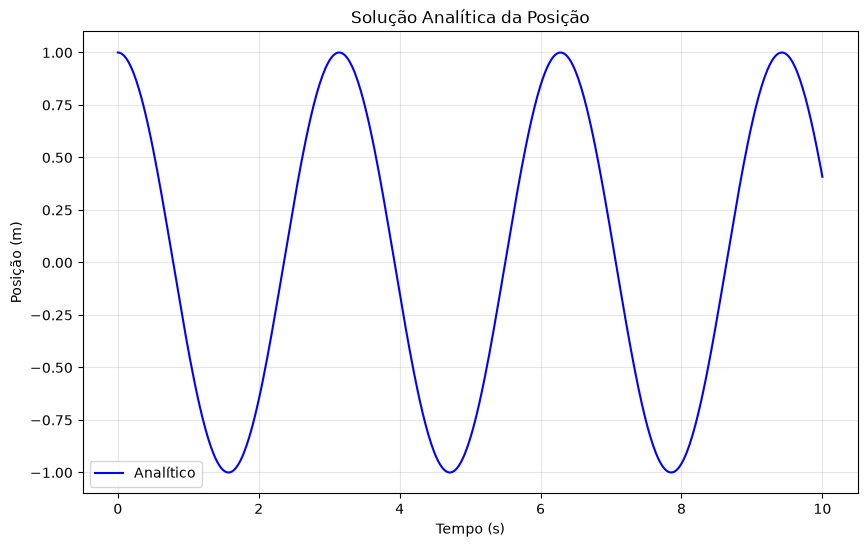

In [17]:
## PLotagem xOt --> Solução Analítica

fig, axs = plt.subplots(figsize=(10,6))

axs.plot(t_eval, x_analitico(t_eval), label='Analítico', color='blue')
axs.set_xlabel('Tempo (s)')
axs.set_ylabel('Posição (m)')
axs.set_title('Solução Analítica da Posição')
axs.legend()
axs.grid(alpha=0.3)

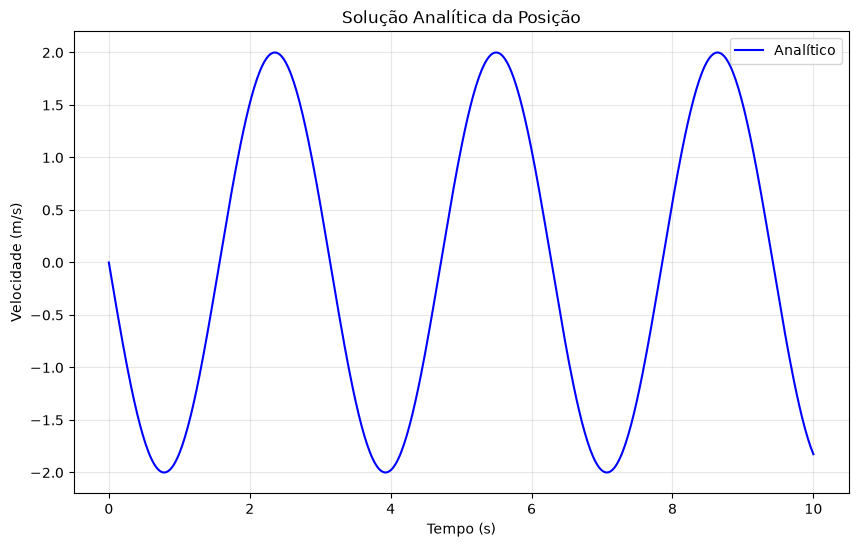

In [ ]:
## PLotagem xOt --> Solução Analítica

fig, axs = plt.subplots(figsize=(10,6))

axs.plot(t_eval, v_analitico(t_eval), label='Analítico', color='blue')
axs.set_xlabel('Tempo (s)')
axs.set_ylabel('Velocidade (m/s)')
axs.set_title('Solução Analítica da Velocidade')
axs.legend()
axs.grid(alpha=0.3)

## Plotagem Númerica

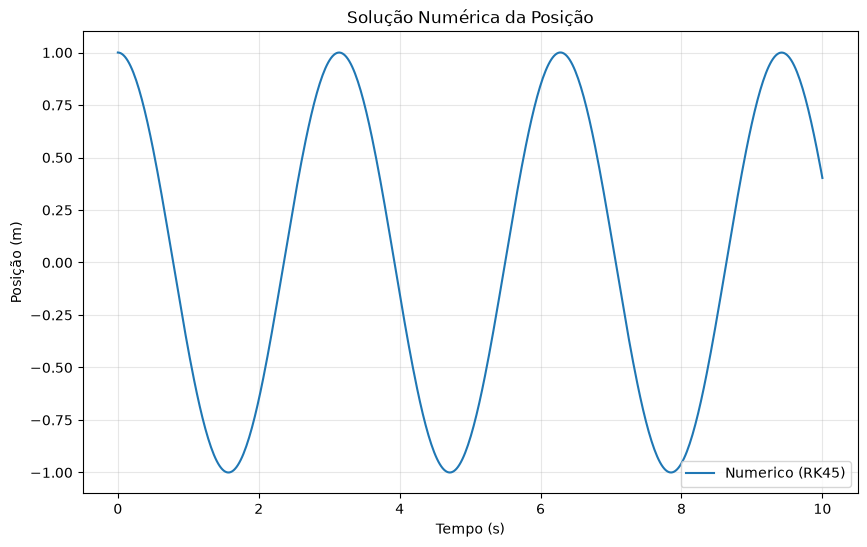

In [27]:
fig, axs = plt.subplots(figsize=(10,6))

axs.plot(t_eval, x_numerico, label="Numerico (RK45)", lw=1.5)
axs.set_xlabel('Tempo (s)')
axs.set_ylabel('Posição (m)')
axs.set_title('Solução Numérica da Posição')
axs.legend()
axs.grid(alpha=0.3)

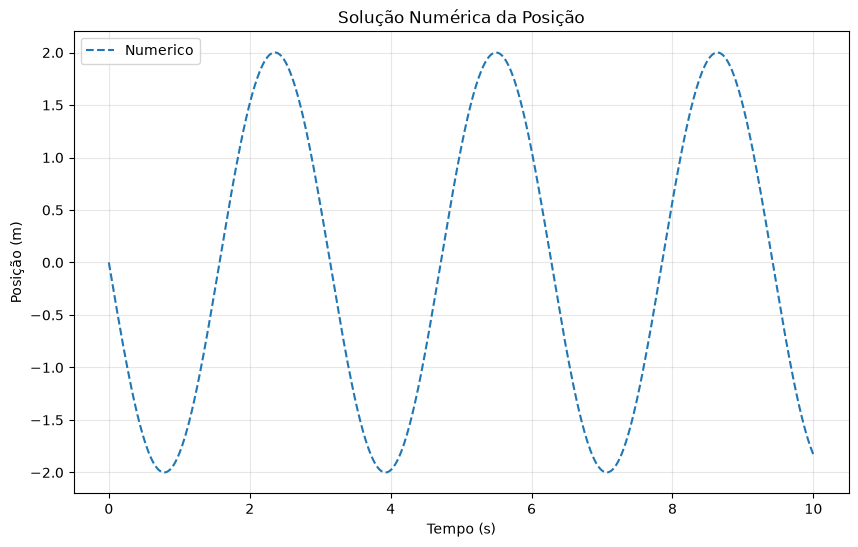

In [30]:
fig, axs = plt.subplots(figsize=(10,6))

axs.plot(t_eval, v_numerico, "--", label="Numerico", lw=1.5)
axs.set_xlabel('Tempo (s)')
axs.set_ylabel('Posição (m)')
axs.set_title('Solução Numérica da Posição')
axs.legend()
axs.grid(alpha=0.3)

In [32]:
erro = np.abs(x_analitico(t_eval) - x_numerico)
print(f"Erro maximo entre solução analitica e numerica: {erro.max():.2e}")

Erro maximo entre solução analitica e numerica: 5.46e-03
